This dataset consists of panel data for Germany, Sweden, and the United States from 2019–2024, combining labour market institutions and macroeconomic variables.

1. DATA DESCRIPTION

- **What variables exist**:

*Control Variables*

i.  <u>Export %</u>

[note*: This was added to control for numerical relativity of a countries dependence on exports in an export exposed industry such as Manufacturing. This allows us to ensure less bias within the Dependent Variable (Manufacturing Unemployment). eg. A higher unemployment rate within manufacturing as manufacturing is more dependent on Exports]

ii. <u>GDP Growth and Nominal Values</u>

[note*: This was added to control for numerical relativity of a countries GDP since it could be dependent on the size of a country. This allows us to ensure less bias within the Dependent Variable (Manufacturing Unemployment). eg. USA is bigger than Germany and Sweden, so nominal values will be larger which could show worse/better results]

iii. <u>Manufacturing Value Added (Missingness for USA between 2022 - 2024)</u>

[note*: THis measures how much of the GDP is added from the industry of Manufacturing. This was added to control for the relative size of the manufacturing industry within a country. This allows us to ensure less bias within the Dependent Variable (Manufacturing Unemployment). eg. USA is bigger than Germany and Sweden, so nominal values will be larger which could show worse/better results]

iv. <u>VAPGDPMA - Manufacturing Value Added for USA - used to impute data for iii's missingness</u>

[note*: Used to impute for 2022 - 2024 USA, but better checked in for Robustness Checks later]

[As this data is used for relative control, there is nothing expected from the variables above, merely that it act as an appropriate baseline.]


*Dependent Variables*

i. <u>Manufacturing Employment</u>

[note*: Manufacturing is a heavily exposed industry towards the tested natural epidemics like COVID-19, and therefore acts as a highly elastic case study]

[Manufacturing Unemployment is expected to increase during the COVID-19 pandemic and recover afterward due to social-distancing policies. This makes manufacturing workers unable to work as much as they initial could- as now, there are limitations to the number of people allowed to be present, if at all.]

*Independent Variables ("COORD.xlsx)*

i. <u>Union Density</u>

[note*: Union Density differs from USA, Germany and Sweden due to the different benefits each country provides to participate in unions via streams like regulations, policies, instituional structure or so on. Missing data in COORD from 2020 - 2024 is resolved by using 2019 data as a proxy. COORD is a time in-variant variable, and therefore it is appropriate for this case.]

ii. <u>Labour Market Coordination (COORD)</u>

[note*: COORD is a (1) - (5) rating on how centralised and organised are wage negotiations between workers, firms, and government. As a measure, it displays whether wage is set by firms (1) or collectively at an industry or national level (5)]

iii. <u>Collective Bargaining Coverage</u>

[note*: Collective Bargaining Coverage is the measure of (1) - (5) for the extent to which the decisions made by the institutions (workers, firms, government) effect the wage on an industry or national scale. eg. Manufacturing wage increases may effect wages within the transportation and automobile industry]

- **Expectations**

With higher Union Density, Labour Market Coordination, and Collective Bargaining coverage- relative to it's countries GDP, GDP growth and Export % and its industries Manufacturing Value Added, that there will be lower Manufacturing Unemployment or vice versa.

2. GRAPHS

**Manufacturing Employment Change Over Time - All Countries**

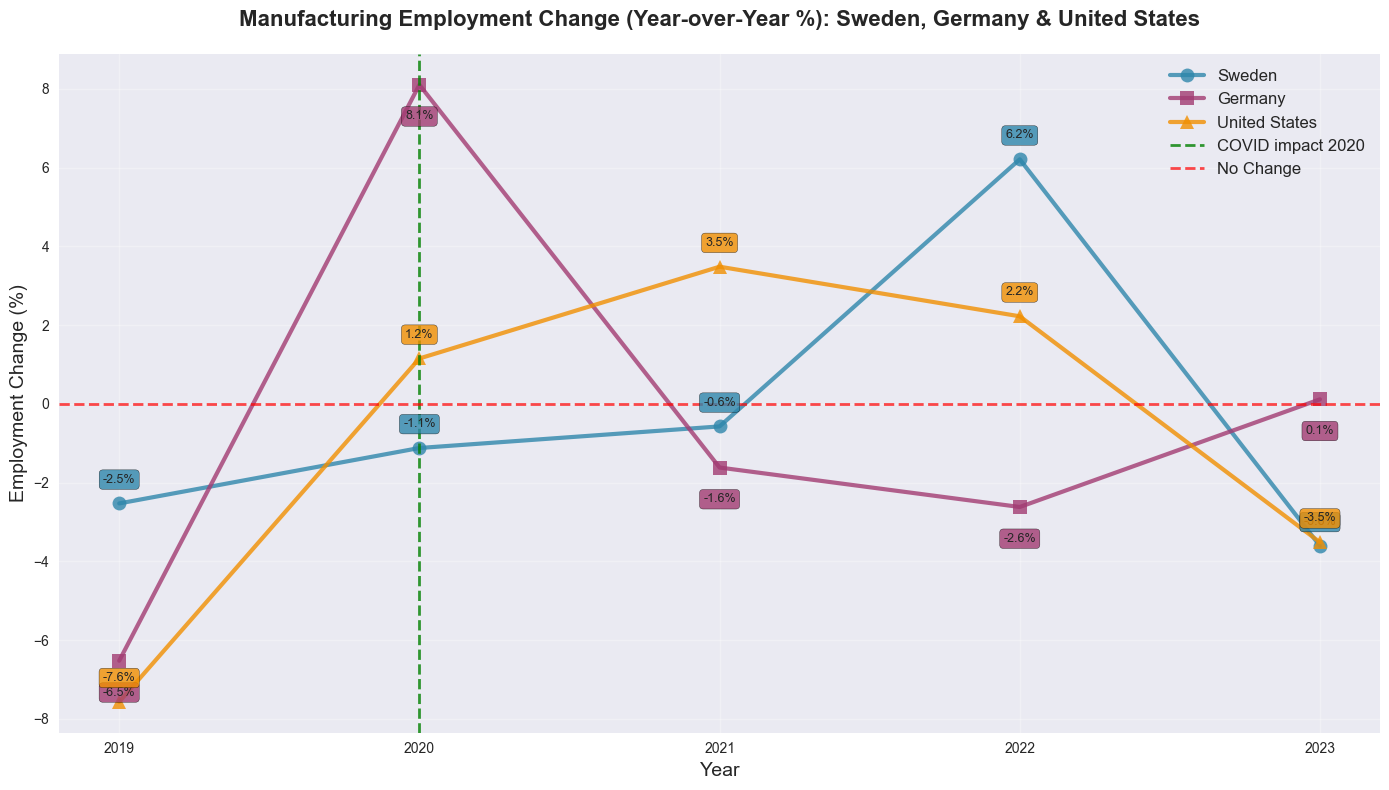

In [18]:
# Combined Manufacturing Employment Change for All Countries
sweden_data = df_employment[df_employment['Country'] == 'Sweden'].iloc[0, 1:]  # Get Sweden row, exclude Country column
germany_data = df_employment[df_employment['Country'] == 'Germany'].iloc[0, 1:]  # Get Germany row, exclude Country column
us_data = df_employment[df_employment['Country'] == 'United States'].iloc[0, 1:]  # Get US row, exclude Country column

years = [col.replace('% Change ', '').split('-')[0] for col in df_employment.columns[1:]]  # Extract years from column names

plt.figure(figsize=(14, 8))

# Plot each country with different colors and markers
plt.plot(years, sweden_data.values, marker='o', linewidth=3, markersize=10, color='#2E86AB', label='Sweden', alpha=0.8)
plt.plot(years, germany_data.values, marker='s', linewidth=3, markersize=10, color='#A23B72', label='Germany', alpha=0.8)
plt.plot(years, us_data.values, marker='^', linewidth=3, markersize=10, color='#F18F01', label='United States', alpha=0.8)

plt.title('Manufacturing Employment Change (Year-over-Year %): Sweden, Germany & United States', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Employment Change (%)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x='2020', color='green', linestyle='--', linewidth=2, alpha=0.8, label='COVID impact 2020')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='No Change')
plt.legend(fontsize=12, loc='best')

# Add value labels on points for each country
for i, (year, value) in enumerate(zip(years, sweden_data.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#2E86AB', alpha=0.8))

for i, (year, value) in enumerate(zip(years, germany_data.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,-25), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#A23B72', alpha=0.8))

for i, (year, value) in enumerate(zip(years, us_data.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F18F01', alpha=0.8))

plt.tight_layout()
plt.show()

2. FIRST ORDER RELATIONSHIPS
- Employment vs GDP
- Employment vs COORD
- Employment vs Export dependence

**Export Dependency as % of GDP Over Time**

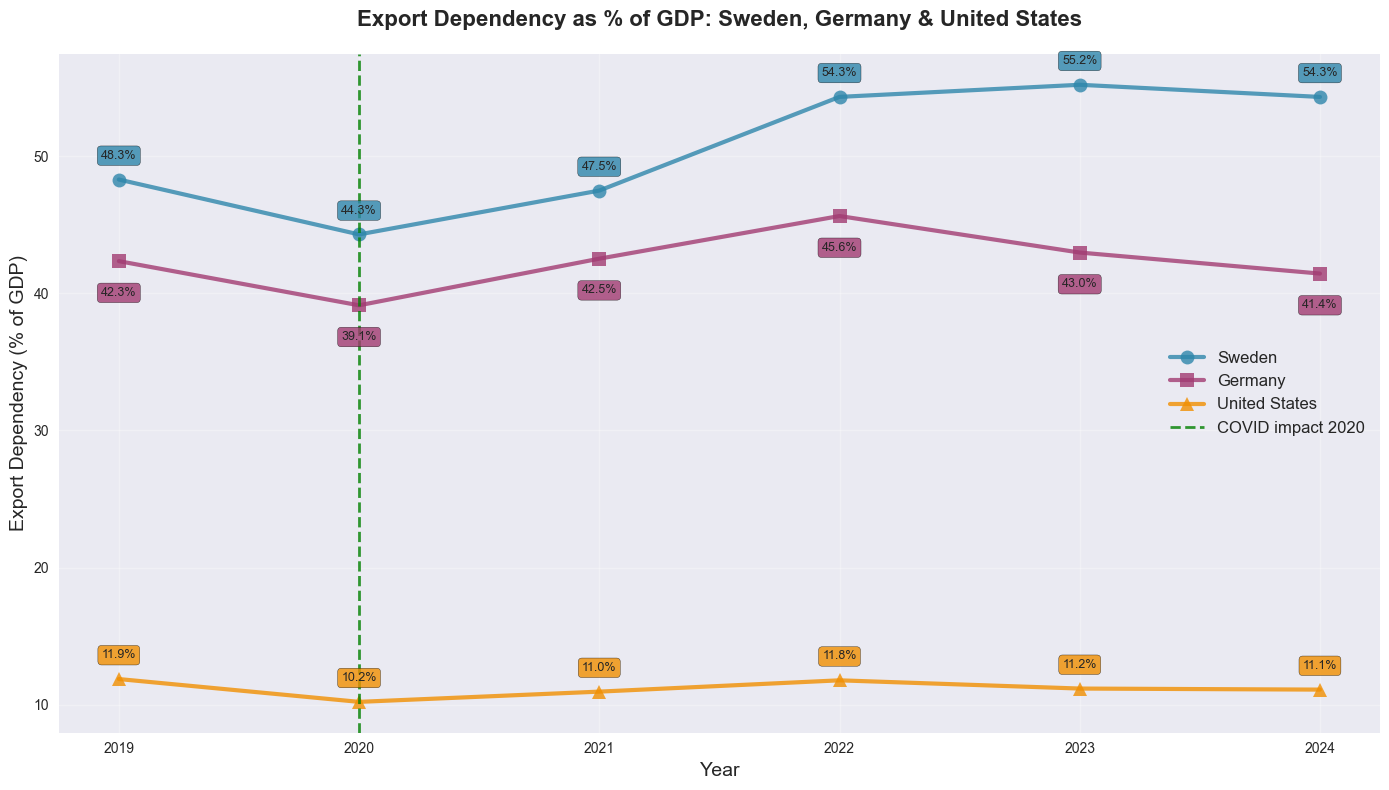

In [16]:
# Export Dependency Graph
sweden_exports = df_exports[df_exports['Country'] == 'Sweden'].iloc[0, 1:]  # Get Sweden row, exclude Country column
germany_exports = df_exports[df_exports['Country'] == 'Germany'].iloc[0, 1:]  # Get Germany row, exclude Country column
us_exports = df_exports[df_exports['Country'] == 'United States'].iloc[0, 1:]  # Get US row, exclude Country column

years_exports = [col.replace('Export Dependency % GDP ', '') for col in df_exports.columns[1:]]  # Extract years from column names

plt.figure(figsize=(14, 8))

# Plot each country with different colors and markers
plt.plot(years_exports, sweden_exports.values, marker='o', linewidth=3, markersize=10, color='#2E86AB', label='Sweden', alpha=0.8)
plt.plot(years_exports, germany_exports.values, marker='s', linewidth=3, markersize=10, color='#A23B72', label='Germany', alpha=0.8)
plt.plot(years_exports, us_exports.values, marker='^', linewidth=3, markersize=10, color='#F18F01', label='United States', alpha=0.8)

plt.title('Export Dependency as % of GDP: Sweden, Germany & United States', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Export Dependency (% of GDP)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x='2020', color='green', linestyle='--', linewidth=2, alpha=0.8, label='COVID impact 2020')
plt.legend(fontsize=12, loc='best')

# Add value labels on points for each country
for i, (year, value) in enumerate(zip(years_exports, sweden_exports.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#2E86AB', alpha=0.8))

for i, (year, value) in enumerate(zip(years_exports, germany_exports.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,-25), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#A23B72', alpha=0.8))

for i, (year, value) in enumerate(zip(years_exports, us_exports.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F18F01', alpha=0.8))

plt.tight_layout()
plt.show()

**GDP Growth Annual % Over Time**

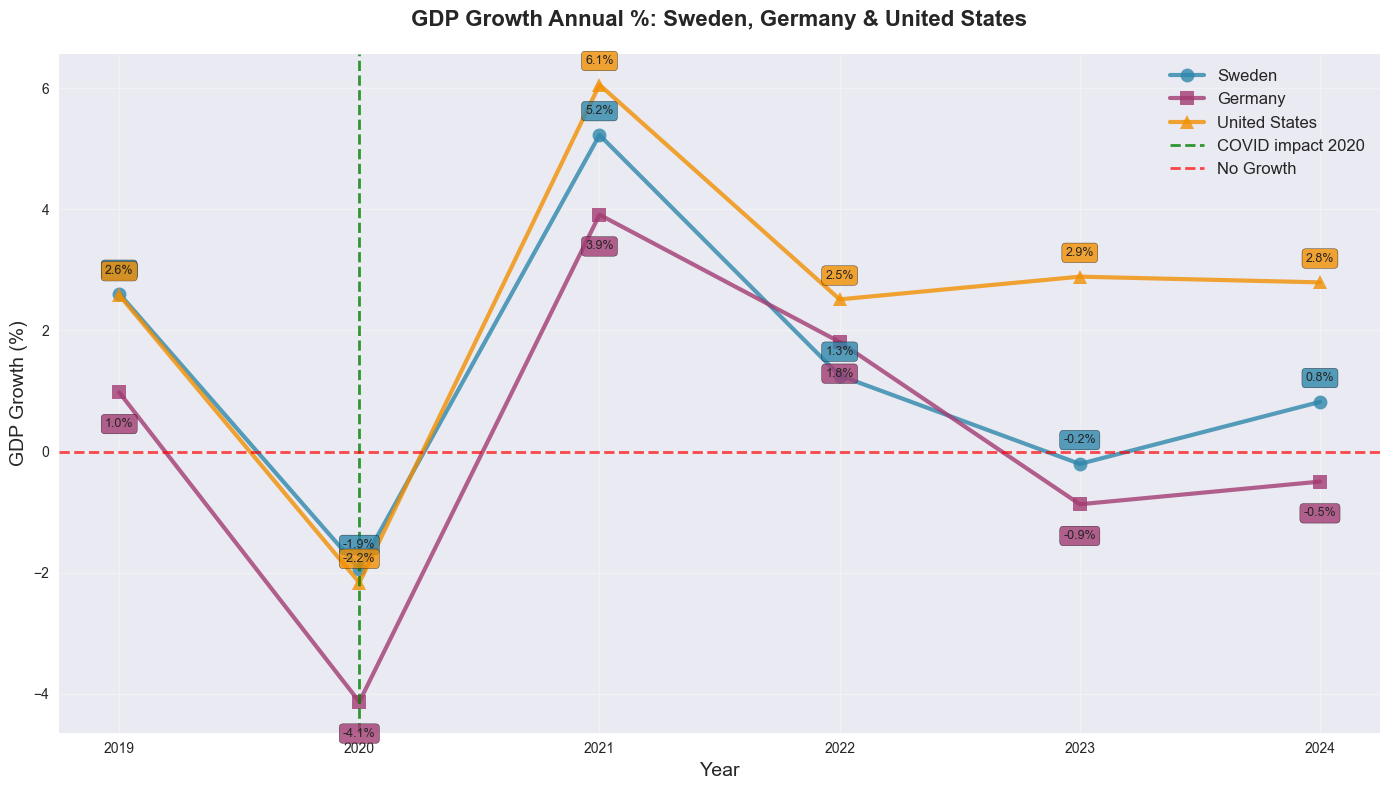

In [17]:
# GDP Growth Graph
sweden_gdp = df_gdp_growth[df_gdp_growth['Country'] == 'Sweden'].iloc[0, 1:]  # Get Sweden row, exclude Country column
germany_gdp = df_gdp_growth[df_gdp_growth['Country'] == 'Germany'].iloc[0, 1:]  # Get Germany row, exclude Country column
us_gdp = df_gdp_growth[df_gdp_growth['Country'] == 'United States'].iloc[0, 1:]  # Get US row, exclude Country column

years_gdp = [col.replace('GDP Growth Annual % ', '') for col in df_gdp_growth.columns[1:]]  # Extract years from column names

plt.figure(figsize=(14, 8))

# Plot each country with different colors and markers
plt.plot(years_gdp, sweden_gdp.values, marker='o', linewidth=3, markersize=10, color='#2E86AB', label='Sweden', alpha=0.8)
plt.plot(years_gdp, germany_gdp.values, marker='s', linewidth=3, markersize=10, color='#A23B72', label='Germany', alpha=0.8)
plt.plot(years_gdp, us_gdp.values, marker='^', linewidth=3, markersize=10, color='#F18F01', label='United States', alpha=0.8)

plt.title('GDP Growth Annual %: Sweden, Germany & United States', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('GDP Growth (%)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x='2020', color='green', linestyle='--', linewidth=2, alpha=0.8, label='COVID impact 2020')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='No Growth')
plt.legend(fontsize=12, loc='best')

# Add value labels on points for each country
for i, (year, value) in enumerate(zip(years_gdp, sweden_gdp.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#2E86AB', alpha=0.8))

for i, (year, value) in enumerate(zip(years_gdp, germany_gdp.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,-25), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#A23B72', alpha=0.8))

for i, (year, value) in enumerate(zip(years_gdp, us_gdp.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F18F01', alpha=0.8))

plt.tight_layout()
plt.show()

**Union Density Over Time**

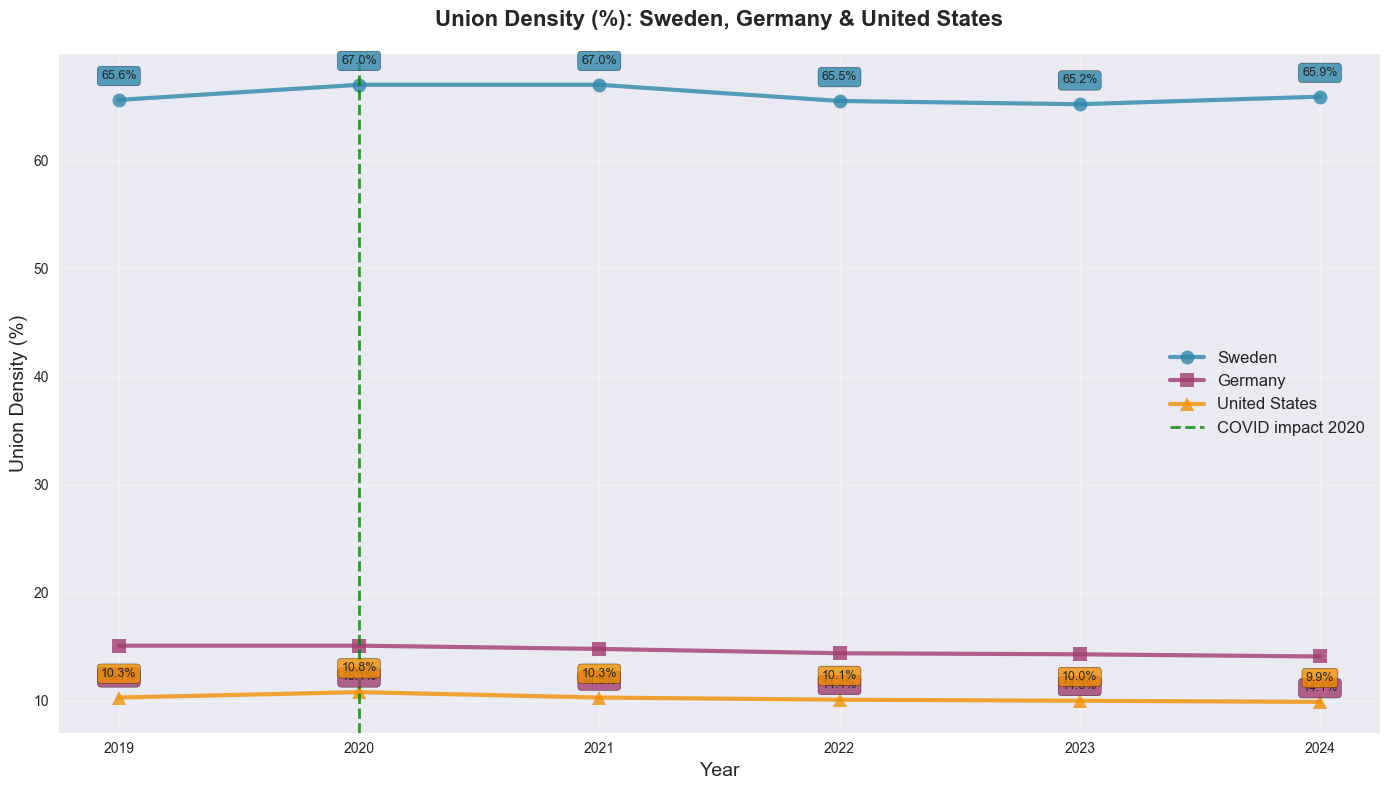

In [20]:
# Union Density Graph
sweden_union = df_union_density[df_union_density['Country'] == 'Sweden'].iloc[0, 1:]
germany_union = df_union_density[df_union_density['Country'] == 'Germany'].iloc[0, 1:]
us_union = df_union_density[df_union_density['Country'] == 'United States'].iloc[0, 1:]

years_union = [col.replace('Union Density ', '') for col in df_union_density.columns[1:]]

plt.figure(figsize=(14, 8))

plt.plot(years_union, sweden_union.values, marker='o', linewidth=3, markersize=10, color='#2E86AB', label='Sweden', alpha=0.8)
plt.plot(years_union, germany_union.values, marker='s', linewidth=3, markersize=10, color='#A23B72', label='Germany', alpha=0.8)
plt.plot(years_union, us_union.values, marker='^', linewidth=3, markersize=10, color='#F18F01', label='United States', alpha=0.8)

plt.title('Union Density (%): Sweden, Germany & United States', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Union Density (%)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x='2020', color='green', linestyle='--', linewidth=2, alpha=0.8, label='COVID impact 2020')
plt.legend(fontsize=12, loc='best')

for i, (year, value) in enumerate(zip(years_union, sweden_union.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#2E86AB', alpha=0.8))

for i, (year, value) in enumerate(zip(years_union, germany_union.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,-25), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#A23B72', alpha=0.8))

for i, (year, value) in enumerate(zip(years_union, us_union.values)):
    plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F18F01', alpha=0.8))

plt.tight_layout()
plt.show()

**Manufacturing Value Added (% of GDP) Over Time**

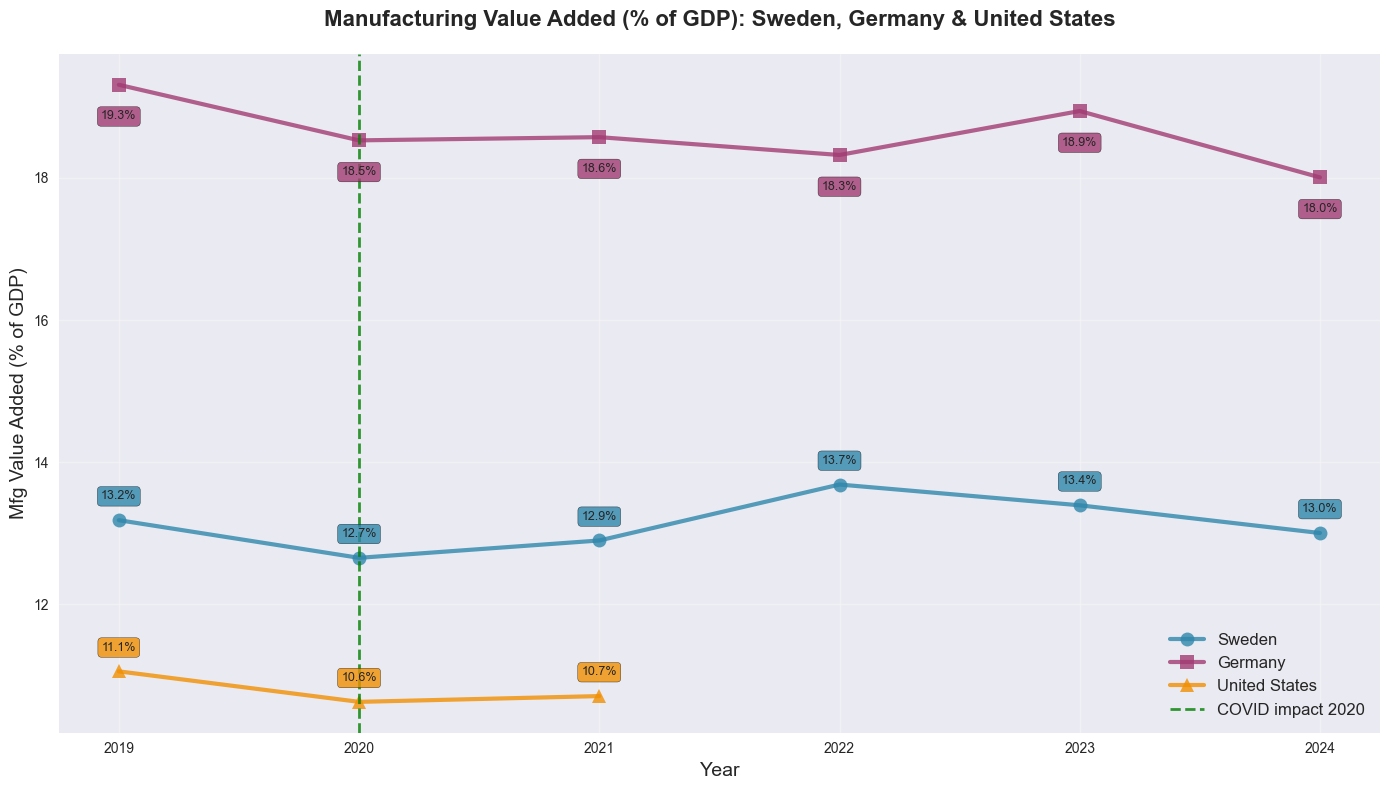

In [21]:
# Manufacturing Value Added Graph
sweden_mfg = df_mfg_value_added[df_mfg_value_added['Country'] == 'Sweden'].iloc[0, 1:]
germany_mfg = df_mfg_value_added[df_mfg_value_added['Country'] == 'Germany'].iloc[0, 1:]
us_mfg = df_mfg_value_added[df_mfg_value_added['Country'] == 'United States'].iloc[0, 1:]

years_mfg = [col.replace('Mfg Value Added % GDP ', '') for col in df_mfg_value_added.columns[1:]]

plt.figure(figsize=(14, 8))

plt.plot(years_mfg, sweden_mfg.values, marker='o', linewidth=3, markersize=10, color='#2E86AB', label='Sweden', alpha=0.8)
plt.plot(years_mfg, germany_mfg.values, marker='s', linewidth=3, markersize=10, color='#A23B72', label='Germany', alpha=0.8)
plt.plot(years_mfg[0:3], us_mfg.values[0:3], marker='^', linewidth=3, markersize=10, color='#F18F01', label='United States', alpha=0.8)

plt.title('Manufacturing Value Added (% of GDP): Sweden, Germany & United States', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Mfg Value Added (% of GDP)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x='2020', color='green', linestyle='--', linewidth=2, alpha=0.8, label='COVID impact 2020')
plt.legend(fontsize=12, loc='best')

for i, (year, value) in enumerate(zip(years_mfg, sweden_mfg.values)):
    if pd.notna(value):
        plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2E86AB', alpha=0.8))

for i, (year, value) in enumerate(zip(years_mfg, germany_mfg.values)):
    if pd.notna(value):
        plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,-25), ha='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#A23B72', alpha=0.8))

for i, (year, value) in enumerate(zip(years_mfg[0:3], us_mfg.values[0:3])):
    if pd.notna(value):
        plt.annotate(f'{value:.1f}%', (years_mfg[i], value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#F18F01', alpha=0.8))

plt.tight_layout()
plt.show()

**VAPGDPMA (% of GDP) Over Time**

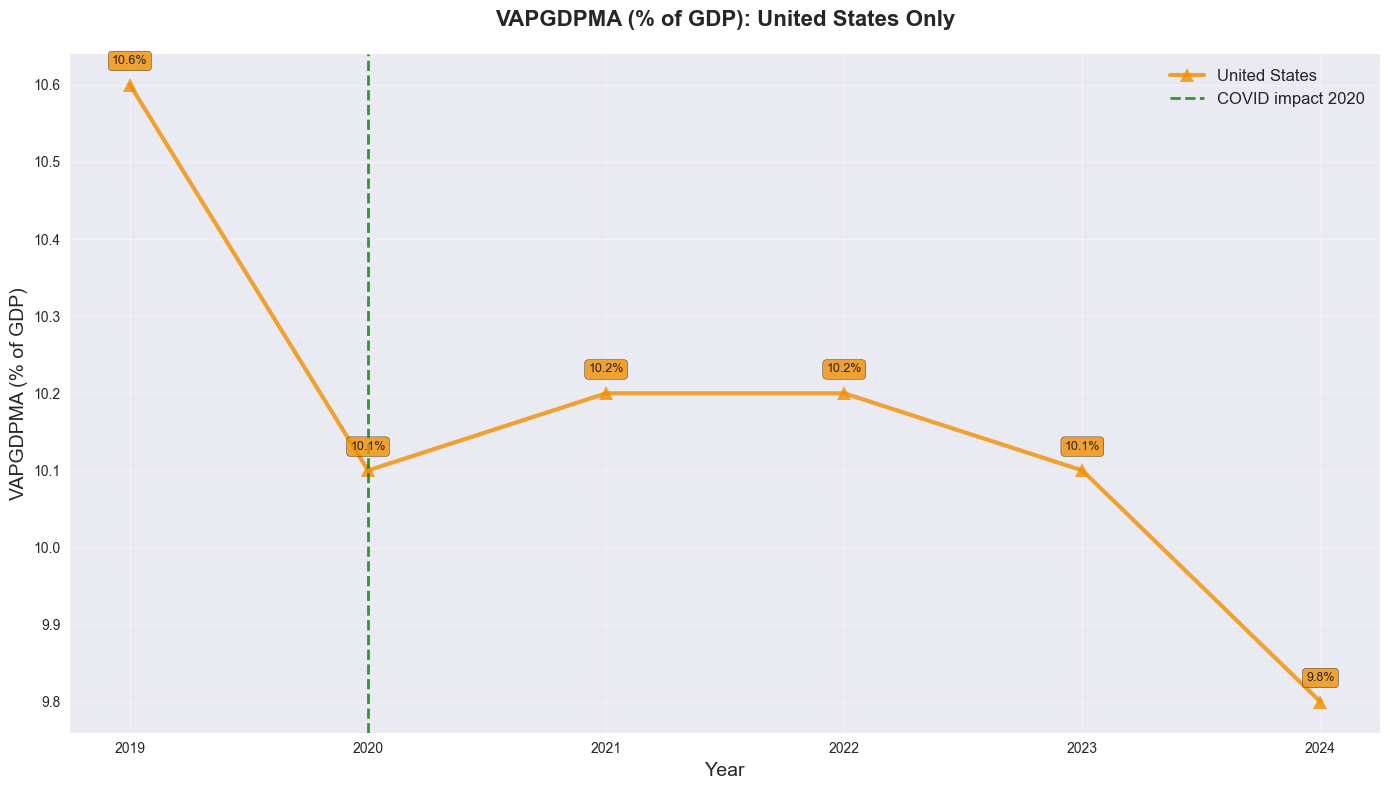

In [22]:
# VAPGDPMA Graph (USA only - no data for Sweden and Germany)
us_vapgdpma = df_vapgdpma[df_vapgdpma['Country'] == 'United States'].iloc[0, 1:]

years_vapgdpma = [col.replace('VAPGDPMA(1) ', '') for col in df_vapgdpma.columns[1:]]

plt.figure(figsize=(14, 8))

# Only USA has data for VAPGDPMA
plt.plot(years_vapgdpma, us_vapgdpma.values, marker='^', linewidth=3, markersize=10, color='#F18F01', label='United States', alpha=0.8)

plt.title('VAPGDPMA (% of GDP): United States Only', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('VAPGDPMA (% of GDP)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x='2020', color='green', linestyle='--', linewidth=2, alpha=0.8, label='COVID impact 2020')
plt.legend(fontsize=12, loc='best')

for i, (year, value) in enumerate(zip(years_vapgdpma, us_vapgdpma.values)):
    if pd.notna(value):
        plt.annotate(f'{value:.1f}%', (year, value), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#F18F01', alpha=0.8))

plt.tight_layout()
plt.show()

3. Analysis

Variables

**Manufacturing Employment:** There is significant cross-country variability and volatility in manufacturing employment. Significant differences exist in the employment responses during COVID-19: Germany exhibits a significant positive spike in 2020, whilst Sweden experiences a little fall and the United States has a modest increase. Different adjustment patterns are seen in subsequent years, with Sweden reaching its peak later (2022) and the US and Sweden both declining in 2023. Although the trend did not follow the expectation that employment would fall, there may be a few country-invariant reasons for all countries having an increase in employment as employment does not adjust one-for-one with output, firms may retain workers during temporary downturns, leading to divergence between GDP and employment dynamics.

**Export Dependence:** Although it varies greatly between nations, export dependency is very steady over time. Sweden continuously shows the greatest reliance on exports (over 50% in subsequent years), followed by Germany (around 40–45%), and the United States (about 10–12%). This implies that export dependency is not a cyclical variable but rather a structural trait.

**GDP Growth:** Over the course of the sample period, with a steep decline in 2020 and a robust recovery in 2021 in every country. With 2.5% - 3.5. the being the average growth rate for healthy countries, the jumps of USA (-2.2 to 6.1%), Sweden (-1.9% - 6.2%) and Germany (-4.1% to 3.9%), GDP growth exhibits notable volatility. The COVID-19 shock and recovery cycle is reflected in this. Germany performs worse after 2021, including negative growth in subsequent years, while the United States continues to grow at a very steady rate beyond 2021. Sweden exhibits moderate oscillations between these extremes.

**Manufacturing Value Added (% of GDP):** Additionally, manufacturing value added has remained relatively steady over time, with the United States having the lowest proportion (~10–11%), Sweden at moderate levels (~13%), and Germany keeping the largest share (~18–19%). The fact that there are relatively slight variations during COVID suggests that even in times of economic stress, industrial structure does not alter quickly.

**Union Density:** Union density exhibits significant cross-national variations but little change over time. Germany has a moderate union density (~14–15%), the United States has a low union density (~10%), and Sweden has a very high union density (~65%). This demonstrates the durability and general time-invariance of labor market institutions.


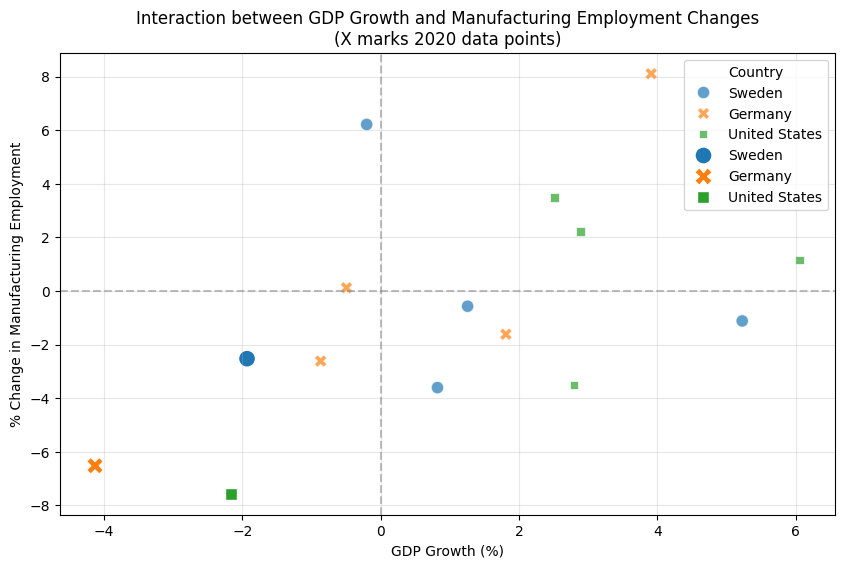

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_gdp = pd.read_csv('data/clean/GDP_growth_annual.csv')
df_emp = pd.read_csv('data/clean/%Change in Manufacturing Employment.csv')

# Melt GDP data
df_gdp_long = df_gdp.melt(id_vars='Country', var_name='Year', value_name='GDP_Growth')
df_gdp_long['Year'] = df_gdp_long['Year'].str.extract(r'(\d{4})').astype(int)

# Melt employment data
df_emp_long = df_emp.melt(id_vars='Country', var_name='Period', value_name='Emp_Change')
df_emp_long['Year'] = df_emp_long['Period'].str.extract(r'(\d{4})$').astype(int)  # Extract the end year

# Merge
df = pd.merge(df_gdp_long, df_emp_long, on=['Country', 'Year'])

# Plot
plt.figure(figsize=(10, 6))
df['is_2020'] = df['Year'] == 2020
sns.scatterplot(data=df[~df['is_2020']], x='GDP_Growth', y='Emp_Change', hue='Country', style='Country', s=80, alpha=0.7, palette='tab10')
sns.scatterplot(data=df[df['is_2020']], x='GDP_Growth', y='Emp_Change', hue='Country', style='Country', s=150, marker='X', palette='tab10')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Interaction between GDP Growth and Manufacturing Employment Changes\n(X marks 2020 data points)')
plt.xlabel('GDP Growth (%)')
plt.ylabel('% Change in Manufacturing Employment')
plt.legend(title='Country')
plt.grid(True, alpha=0.3)
plt.show()

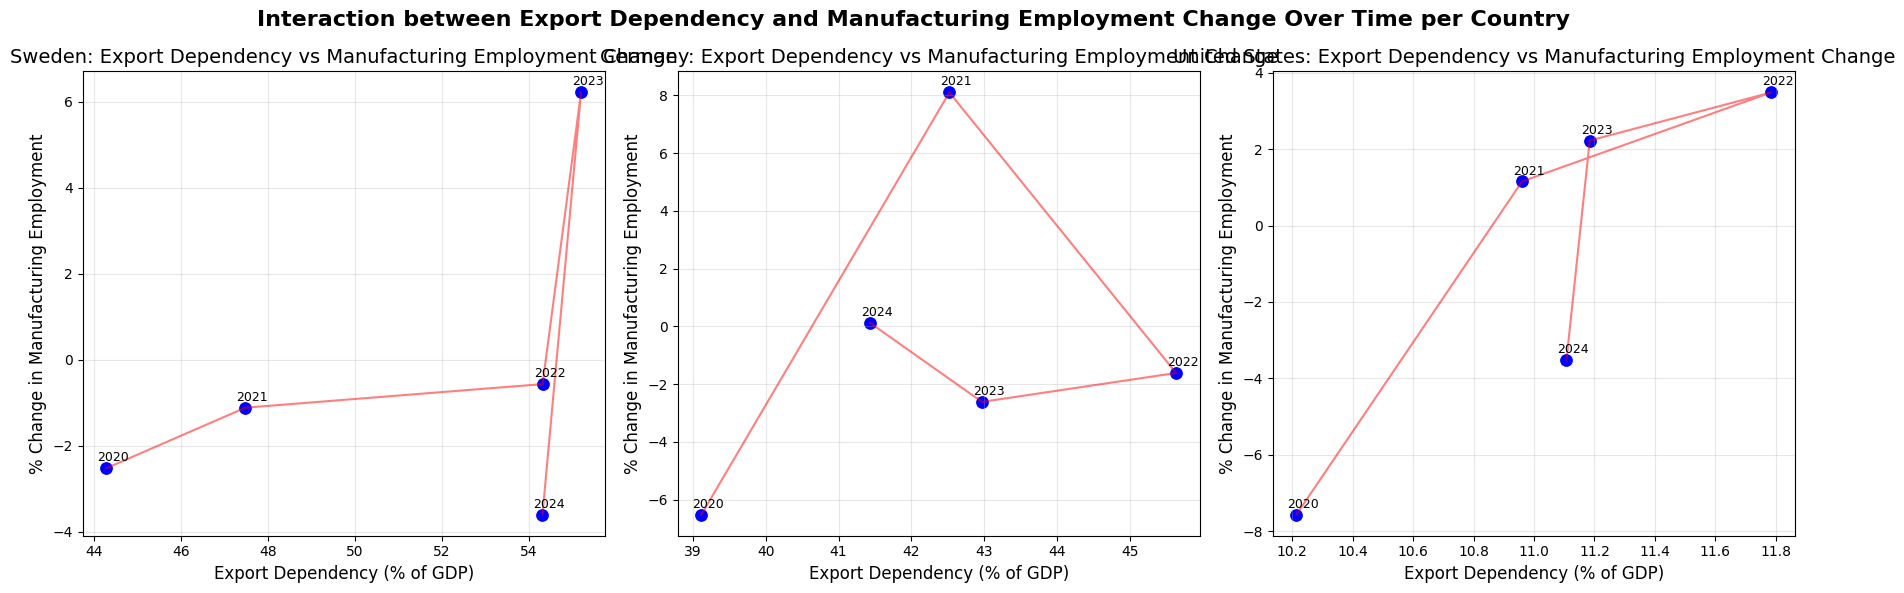

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_exports = pd.read_csv('data/clean/Export_dependency.csv')
df_emp = pd.read_csv('data/clean/%Change in Manufacturing Employment.csv')

# Melt export data
df_exports_long = df_exports.melt(id_vars='Country', var_name='Year', value_name='Export_Dep')
df_exports_long['Year'] = df_exports_long['Year'].str.extract(r'(\d{4})').astype(int)

# Melt employment data
df_emp_long = df_emp.melt(id_vars='Country', var_name='Period', value_name='Emp_Change')
df_emp_long['Year'] = df_emp_long['Period'].str.extract(r'(\d{4})$').astype(int)  # Extract the end year

# Merge
df = pd.merge(df_exports_long, df_emp_long, on=['Country', 'Year'])

# Plot per country
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
countries = df['Country'].unique()

for i, country in enumerate(countries):
    data = df[df['Country'] == country].sort_values('Year')
    sns.scatterplot(data=data, x='Export_Dep', y='Emp_Change', ax=axes[i], color='blue', s=100)
    sns.lineplot(data=data, x='Export_Dep', y='Emp_Change', ax=axes[i], color='red', alpha=0.5, sort=False)
    axes[i].set_title(f'{country}: Export Dependency vs Manufacturing Employment Change', fontsize=14)
    axes[i].set_xlabel('Export Dependency (% of GDP)', fontsize=12)
    axes[i].set_ylabel('% Change in Manufacturing Employment', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    # Add year labels
    for _, row in data.iterrows():
        axes[i].annotate(str(row['Year']), (row['Export_Dep'], row['Emp_Change']), 
                        textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)

plt.suptitle('Interaction between Export Dependency and Manufacturing Employment Change Over Time per Country', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

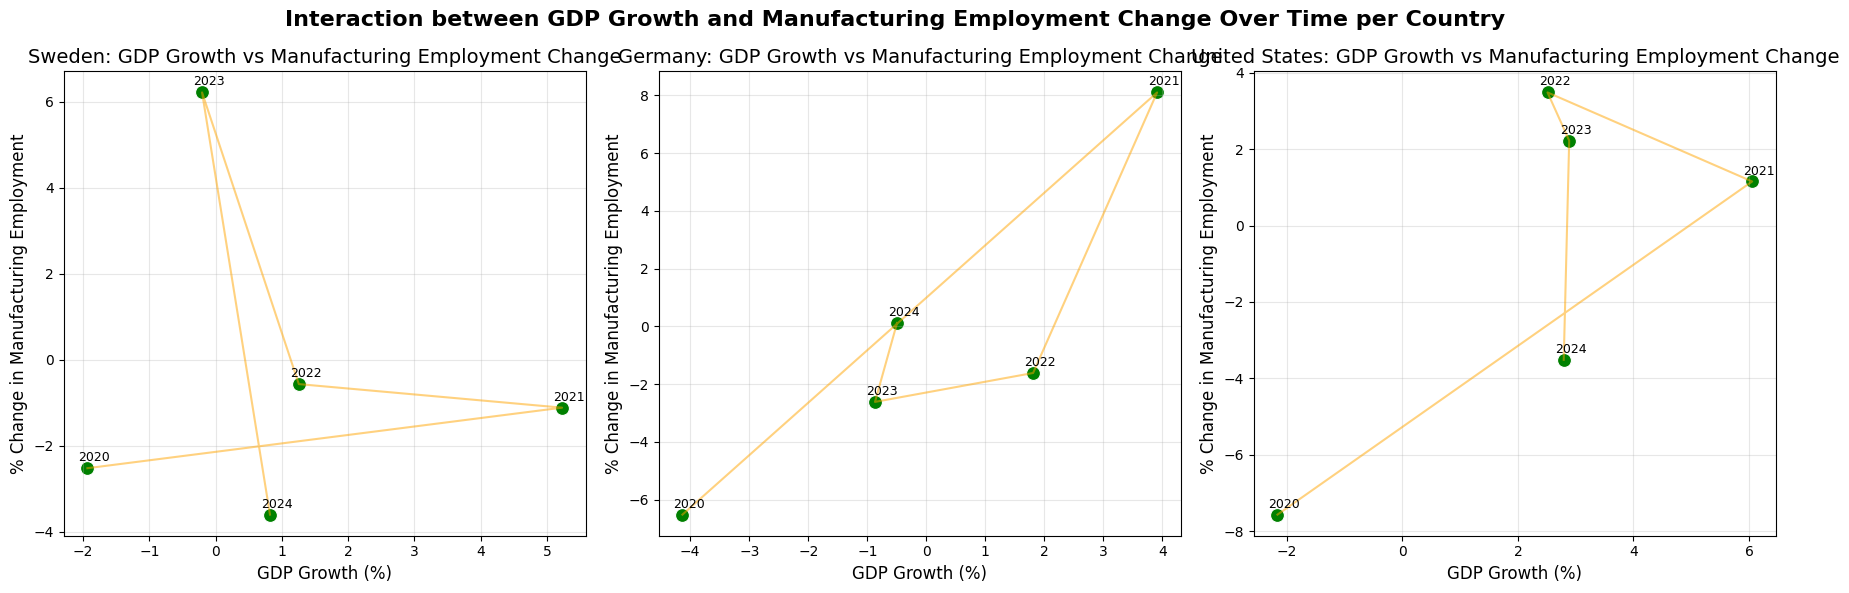

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_gdp = pd.read_csv('data/clean/GDP_growth_annual.csv')
df_emp = pd.read_csv('data/clean/%Change in Manufacturing Employment.csv')

# Melt GDP data
df_gdp_long = df_gdp.melt(id_vars='Country', var_name='Year', value_name='GDP_Growth')
df_gdp_long['Year'] = df_gdp_long['Year'].str.extract(r'(\d{4})').astype(int)

# Melt employment data
df_emp_long = df_emp.melt(id_vars='Country', var_name='Period', value_name='Emp_Change')
df_emp_long['Year'] = df_emp_long['Period'].str.extract(r'(\d{4})$').astype(int)  # Extract the end year

# Merge
df = pd.merge(df_gdp_long, df_emp_long, on=['Country', 'Year'])

# Plot per country
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
countries = df['Country'].unique()

for i, country in enumerate(countries):
    data = df[df['Country'] == country].sort_values('Year')
    sns.scatterplot(data=data, x='GDP_Growth', y='Emp_Change', ax=axes[i], color='green', s=100)
    sns.lineplot(data=data, x='GDP_Growth', y='Emp_Change', ax=axes[i], color='orange', alpha=0.5, sort=False)
    axes[i].set_title(f'{country}: GDP Growth vs Manufacturing Employment Change', fontsize=14)
    axes[i].set_xlabel('GDP Growth (%)', fontsize=12)
    axes[i].set_ylabel('% Change in Manufacturing Employment', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    # Add year labels
    for _, row in data.iterrows():
        axes[i].annotate(str(row['Year']), (row['GDP_Growth'], row['Emp_Change']), 
                        textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)

plt.suptitle('Interaction between GDP Growth and Manufacturing Employment Change Over Time per Country', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

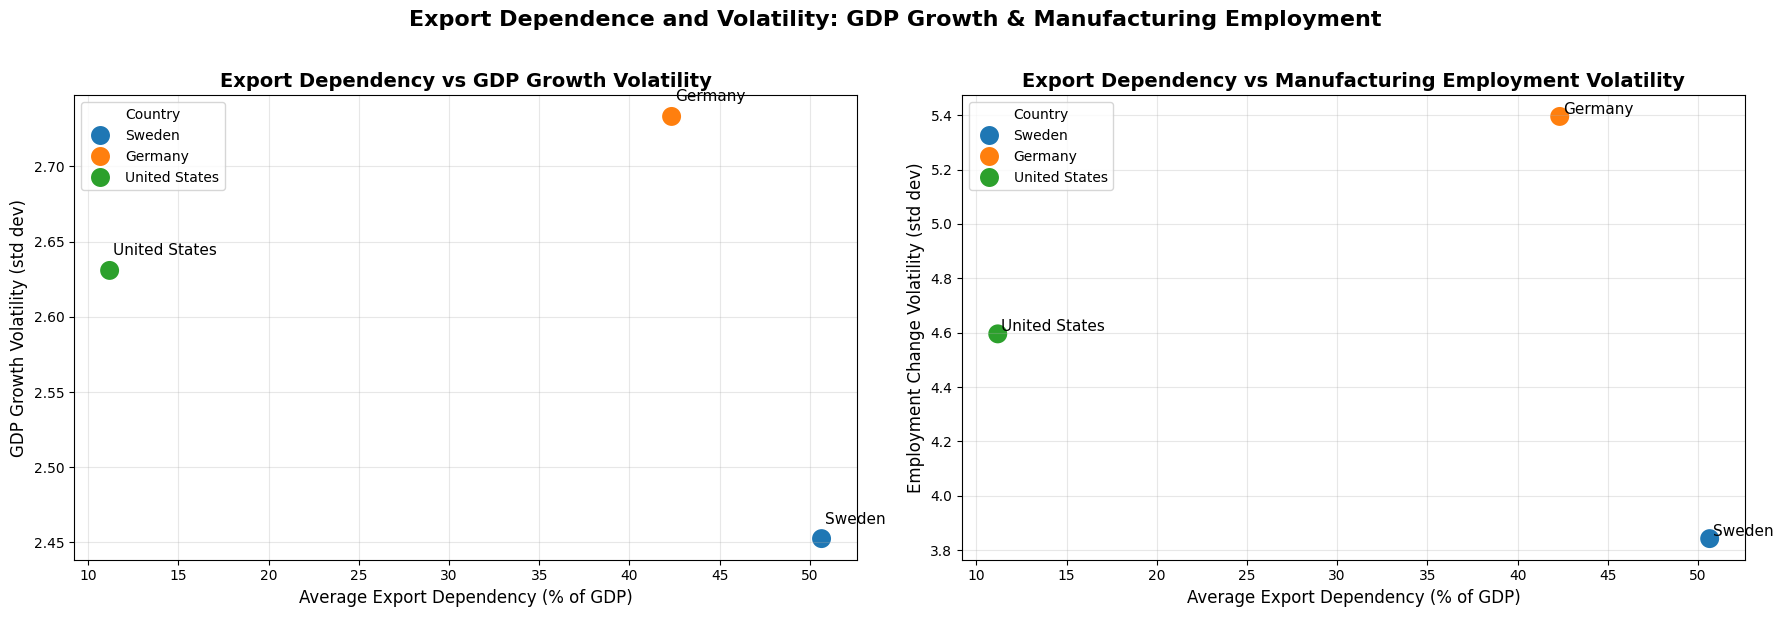

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data for this interaction chart
# If earlier cells are not executed, this ensures the needed tables are available

try:
    df_exports = pd.read_csv('data/clean/Export_dependency.csv')
    df_gdp_growth = pd.read_csv('data/clean/GDP_growth_annual.csv')
    df_employment = pd.read_csv('data/clean/%Change in Manufacturing Employment.csv')
except FileNotFoundError:
    raise FileNotFoundError('One or more required files are missing in data/clean. Ensure Export_dependency.csv, GDP_growth_annual.csv, and %Change in Manufacturing Employment.csv exist.')

export_cols = [col for col in df_exports.columns if 'Export Dependency % GDP' in col]
gdp_cols = [col for col in df_gdp_growth.columns if 'GDP Growth Annual %' in col]
emp_cols = [col for col in df_employment.columns if '% Change' in col]

rows = []
for country in df_exports['Country']:
    exp_avg = df_exports.loc[df_exports['Country'] == country, export_cols].astype(float).mean(axis=1).iloc[0]
    gdp_vol = df_gdp_growth.loc[df_gdp_growth['Country'] == country, gdp_cols].astype(float).std(axis=1).iloc[0]
    emp_vol = df_employment.loc[df_employment['Country'] == country, emp_cols].astype(float).std(axis=1).iloc[0]
    rows.append({'Country': country,
                 'Export_Dependency': exp_avg,
                 'GDP_Volatility': gdp_vol,
                 'Employment_Volatility': emp_vol})

df_interaction = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

sns.lineplot(data=df_interaction.sort_values('Export_Dependency'), x='Export_Dependency', y='GDP_Volatility', hue='Country', marker='o', ax=axes[0], palette='tab10', sort=False)
for _, row in df_interaction.iterrows():
    axes[0].text(row['Export_Dependency'] + 0.2, row['GDP_Volatility'] + 0.01, row['Country'], fontsize=11)
axes[0].set_title('Export Dependency vs GDP Growth Volatility', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Export Dependency (% of GDP)', fontsize=12)
axes[0].set_ylabel('GDP Growth Volatility (std dev)', fontsize=12)
axes[0].grid(alpha=0.3)

sns.lineplot(data=df_interaction.sort_values('Export_Dependency'), x='Export_Dependency', y='Employment_Volatility', hue='Country', marker='o', ax=axes[1], palette='tab10', sort=False)
for _, row in df_interaction.iterrows():
    axes[1].text(row['Export_Dependency'] + 0.2, row['Employment_Volatility'] + 0.01, row['Country'], fontsize=11)
axes[1].set_title('Export Dependency vs Manufacturing Employment Volatility', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Export Dependency (% of GDP)', fontsize=12)
axes[1].set_ylabel('Employment Change Volatility (std dev)', fontsize=12)
axes[1].grid(alpha=0.3)

plt.suptitle('Export Dependence and Volatility: GDP Growth & Manufacturing Employment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


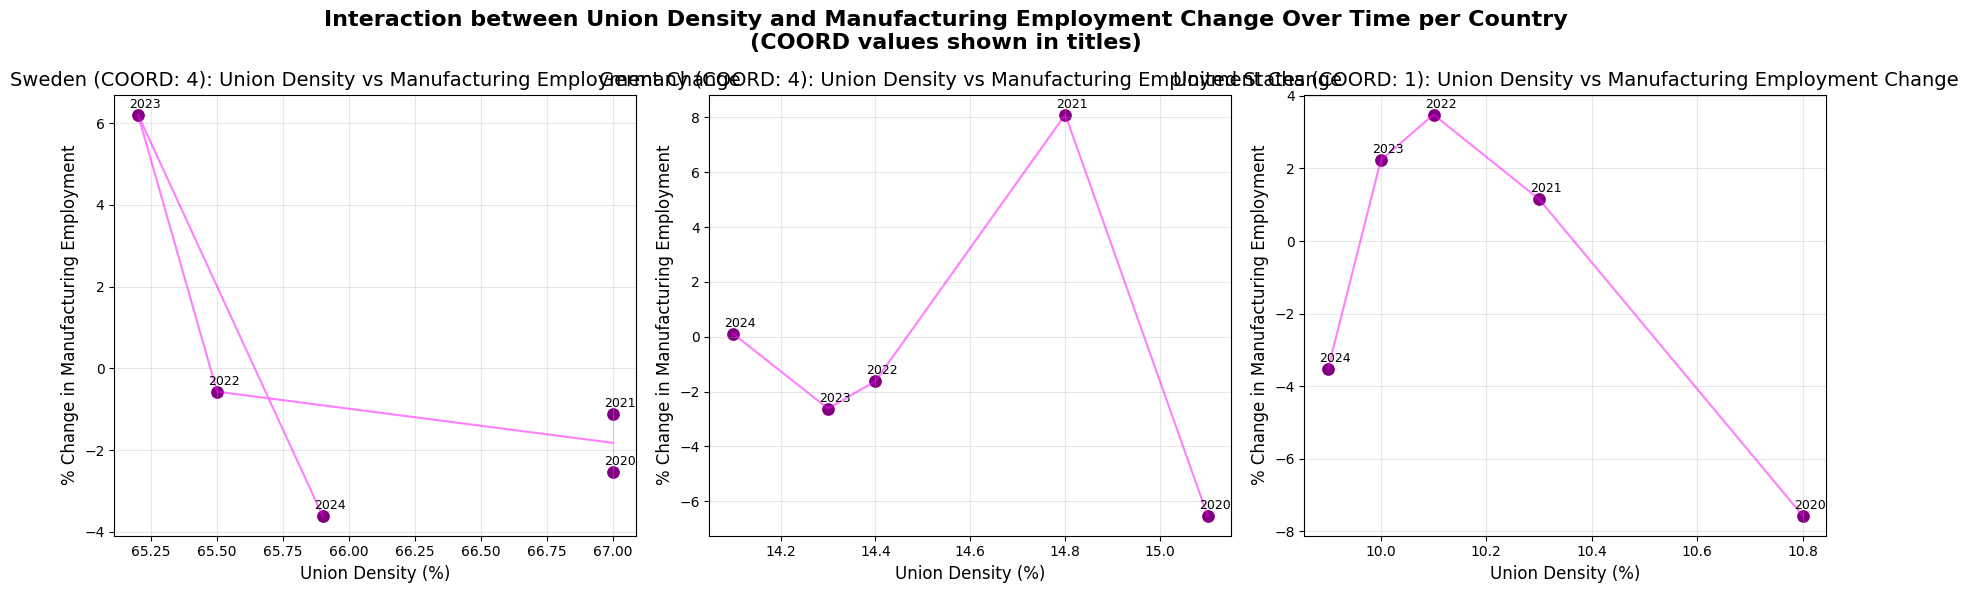

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_union = pd.read_csv('data/clean/Union Density.csv')
df_emp = pd.read_csv('data/clean/%Change in Manufacturing Employment.csv')
df_coord = pd.read_csv('data/clean/COORD_2019.csv')

# Melt union data
df_union_long = df_union.melt(id_vars='Country', var_name='Year', value_name='Union_Density')
df_union_long['Year'] = df_union_long['Year'].str.extract(r'(\d{4})').astype(int)

# Melt employment data
df_emp_long = df_emp.melt(id_vars='Country', var_name='Period', value_name='Emp_Change')
df_emp_long['Year'] = df_emp_long['Period'].str.extract(r'(\d{4})$').astype(int)  # Extract the end year

# Merge union and emp
df = pd.merge(df_union_long, df_emp_long, on=['Country', 'Year'])

# Get COORD values
coord_dict = df_coord.set_index('Country')['Labour Market Coordination (COORD)'].to_dict()

# Plot per country
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
countries = df['Country'].unique()

for i, country in enumerate(countries):
    data = df[df['Country'] == country].sort_values('Year')
    coord_val = coord_dict.get(country, 'N/A')
    sns.scatterplot(data=data, x='Union_Density', y='Emp_Change', ax=axes[i], color='purple', s=100)
    sns.lineplot(data=data, x='Union_Density', y='Emp_Change', ax=axes[i], color='magenta', alpha=0.5, sort=False)
    axes[i].set_title(f'{country} (COORD: {coord_val}): Union Density vs Manufacturing Employment Change', fontsize=14)
    axes[i].set_xlabel('Union Density (%)', fontsize=12)
    axes[i].set_ylabel('% Change in Manufacturing Employment', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    # Add year labels
    for _, row in data.iterrows():
        axes[i].annotate(str(row['Year']), (row['Union_Density'], row['Emp_Change']), 
                        textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)

plt.suptitle('Interaction between Union Density and Manufacturing Employment Change Over Time per Country\n(COORD values shown in titles)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Interaction

- **GDP Growth & Employment:** Employment responses vary greatly in 2020 despite a steep decline in GDP, indicating a poor first-order link between macroeconomic conditions and employment results. The Graph displaying this interaction showcases this relationship, wherein the points are scattered without mostly any direction; some points such as Germany(GDPchange: ~4% and ManuEmploymentChange: ~8%) and USA(GDPchange: ~3% and ManuEmploymentChange: ~2%) opposing that the relationship between GDP Growth and Employment is negative. This indicates that macroeconomic shocks do not directly effect employment changes, and display that there are other factors such as policy interventions or labour market institutions that influence employment outcomes.

- **Export Dependence & Employment/GDP Growth:** Export dependence seems to be linked to higher variability in manufacturing job outcomes and GDP growth, especially in Germany, which shows significant variations in addition to modest export reliance. This is in line with the hypothesis that economies with greater trade exposure are more susceptible to shocks from the outside world. But not all nations have the same relationship. Despite its comparatively low reliance on exports, the United States nevertheless faces significant volatility, especially during the 2020 COVID-19 pandemic. In a similar vein, Sweden's trends do not entirely support a definite positive correlation.

Consequently, the evidence is conflicting and insufficient to demonstrate a strong association without additional econometric research, even though the observed patterns are generally compatible with the theoretical expectation. The COVID-19 shock appears to dominate the variation across all countries, suggesting that global macro shocks may outweigh structural differences such as export dependence in the short run.

- **Institutional Variables (Union Density / COORD) & Employment:** Sweden and Germany both exhibit relatively strong labour market institutions, but their approaches to employment are very different. These variations suggest that rather than merely lowering volatility, labor market institutions may have an impact on the timing and spread of shocks. Specifically, Germany's quick increase indicates a stronger front-loaded adjustment despite comparable institutional strength, whereas Sweden's delayed response shows a smoothing or lagging adjustment process. The difference between Sweden and Germany indicates that coordination may affect the timing and distribution of labor market adjustments over time rather than consistently lowering volatility.

Why? - In large part this difference despite similarly built labout market institutions has to do with their COVID-19 job policies: Kurzarbeit (Germany) and Korttidsarbete (Sweden). The structures of which these policies were built could directly explain the oddity between Germany's instant spike and Swedens lagged spike. Both the policies reimbursed workers for lost hours focused on industrial sectors, escpecially Kurzarbeit. However, where Kurzarbeit is implemented for employers to calculate it on payroll to be quickly reimbursed, Korttidsarbete heavily relied on existing collective bargaining agreements often bringing in union negotiations which can slow the process significantly as unions, governments and employers often take time to come to an agreement.

On the other hand, with USA holding a weak labour market institution, it held no large spikes or lags.

[Referenced from the OECD and IMF]

- **Manufacturing Value & Manufacturing Employment (USA):** Manufacturing employment and manufacturing value added in the US show generally comparable directional patterns over time, especially in the post-COVID era when both variables show a slow drop. Nonetheless, employment exhibits significantly higher volatility than value added, indicating that labor market adjustments are more susceptible to transient changes than the underlying industrial structure. 

Why? - Employment may react more directly to shifts in economic activity in less coordinated labor markets, as evidenced by the tighter alignment between value added and employment in the US as opposed to the divergence seen in Sweden and Germany.

Intepretation of Tripartites - Governments, Firms and Unions

The substantial differences in all variables highlight cross-country heterogeneity. Employment outcomes are expected to be significantly influenced by labor market institutions, as seen by persistent disparities in union density and coordination. These establishments might:
- smooth adjustments
- delay responses
- reduce volatility

5. Modelling Implications

Limitations

- COORD variable is treated as time-invariant using 2019 values, which may not fully capture institutional changes during the COVID-19 period.
- 2020 observation for Germany's Manufacturing Employment includes imputed data, which may introduce measurement error.
- 2022 - 2024 observation for USA's Manufacturing Value added includes imputed data, which may introduce measurement error. 
- The small sample size (three countries over a short time period) limits the ability to draw strong statistical conclusions. These factors should be considered when interpreting the results

It is important to note that these findings are based on exploratory analysis and do not establish causal relationships, but rather highlight patterns that inform the subsequent empirical strategy.The EDA implies that GDP growth should be included as a key control variable due to its strong variation over time. Export dependence may act as a channel through which global shocks affect domestic outcomes. Institutional variables such as COORD and union density are likely to be important explanatory variables, particularly in explaining cross-country heterogeneity. The observed divergence between GDP and employment also suggests that additional factors beyond macroeconomic conditions should be considered. Due to these potentially hidden relationships if not otherwise considered, the control variables are in place to adjust for those patterns.

Note*: No major transformations appear necessary, as most variables are already expressed in percentage terms.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_mfg = pd.read_csv('data/clean/%Manufacturing Value Added Nominal.csv')  # Assuming this is the file, or adjust if needed
df_emp = pd.read_csv('data/clean/%Change in Manufacturing Employment.csv')

# Filter for USA
df_mfg_usa = df_mfg[df_mfg['Country'] == 'United States']
df_emp_usa = df_emp[df_emp['Country'] == 'United States']

# Melt mfg data
df_mfg_long = df_mfg_usa.melt(id_vars='Country', var_name='Year', value_name='Mfg_Value_Added')
df_mfg_long['Year'] = df_mfg_long['Year'].str.extract(r'(\d{4})').astype(int)

# Melt employment data
df_emp_long = df_emp_usa.melt(id_vars='Country', var_name='Period', value_name='Emp_Change')
df_emp_long['Year'] = df_emp_long['Period'].str.extract(r'(\d{4})$').astype(int)  # Extract the end year

# Merge
df = pd.merge(df_mfg_long, df_emp_long, on=['Country', 'Year'])

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Mfg_Value_Added', y='Emp_Change', color='orange', s=100)
sns.lineplot(data=df.sort_values('Year'), x='Mfg_Value_Added', y='Emp_Change', color='red', alpha=0.5, sort=False)
plt.title('Manufacturing Value Added vs Manufacturing Employment Change in the United States', fontsize=16, fontweight='bold')
plt.xlabel('Manufacturing Value Added (% of GDP)', fontsize=14)
plt.ylabel('% Change in Manufacturing Employment', fontsize=14)
plt.grid(True, alpha=0.3)
# Add year labels
for _, row in df.iterrows():
    plt.annotate(str(row['Year']), (row['Mfg_Value_Added'], row['Emp_Change']), 
                textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)

plt.tight_layout()
plt.show()